In [1]:
import tensorflow as tf
from tensorflow import keras
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import warnings 
warnings.filterwarnings("ignore")

I0000 00:00:1791061638.649884   54209 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1791061638.712259   54209 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1791061640.077304   54209 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# 1) Dataset Loading & Understanding

### Loading the dataset

In [2]:
train_data = keras.utils.image_dataset_from_directory(
    r"/mnt/d/DeepLearning/datasets/Brain_Tumor_MRI/Training",
    image_size=(224,224),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=42
)

Found 5600 files belonging to 4 classes.
Using 4480 files for training.


I0000 00:00:1791061643.086681   54209 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1751 MB memory:  -> device: 0, name: NVIDIA RTX A2000 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


In [3]:
test_data = keras.utils.image_dataset_from_directory(
    r"/mnt/d/DeepLearning/datasets/Brain_Tumor_MRI/Testing",
    image_size=(224,224),
    batch_size=32,
    seed=42
)

Found 1600 files belonging to 4 classes.


### Checking class names

In [4]:
print(train_data.class_names)

print("Number of Images In Training :", len(train_data) * 32)

['glioma', 'meningioma', 'notumor', 'pituitary']
Number of Images In Training : 4480


In [5]:
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

### Counting images per class

In [6]:
images_to_class = {'glioma':0, 'meningioma':0, 'notumor':0, 'pituitary':0}

for images , labels in train_data:
    for label in labels:
        label_name = train_data.class_names[label]
        images_to_class[label_name]+=1
print(images_to_class)
    

{'glioma': 1140, 'meningioma': 1125, 'notumor': 1100, 'pituitary': 1115}


### Visualizing sample images

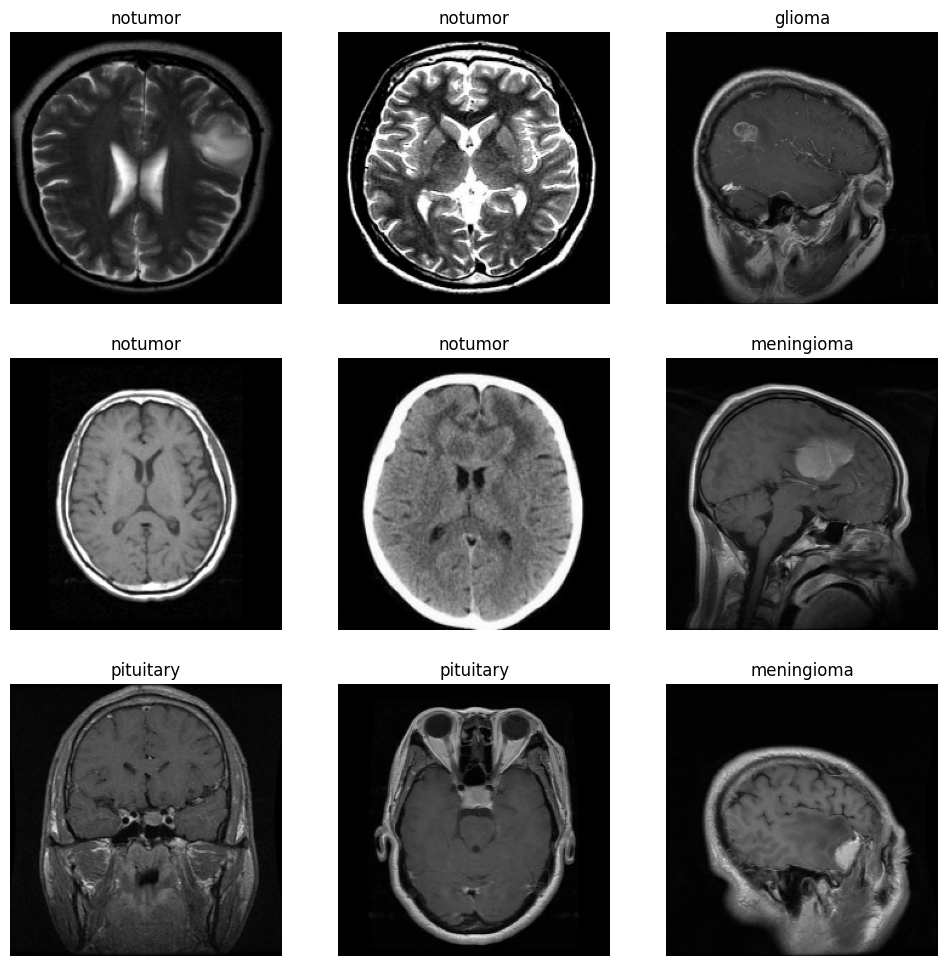

In [7]:
plt.figure(figsize=(12,12))
plt.subplot(3,3,1)
for images, labels in train_data.take(1):

    for i in np.arange(9):
        plt.subplot(3,3,i+1)
        plt.axis("off")
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(train_data.class_names[labels[i].numpy()])

plt.show()

# 2) Dataset Splitting & Preparation

In [8]:
print(test_data.class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [9]:
validation_data = keras.utils.image_dataset_from_directory(
    r"/mnt/d/DeepLearning/datasets/Brain_Tumor_MRI/Training",
    image_size=(224,224),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=42
)

Found 5600 files belonging to 4 classes.
Using 1120 files for validation.


In [10]:
print("Train Images:", len(train_data)*32)
print("Validation Images:", len(validation_data)*32)
print("Test Images:", len(test_data)*32)

Train Images: 4480
Validation Images: 1120
Test Images: 1600


In [11]:
print("Train classes:", train_data.class_names)
print("Validation classes:", validation_data.class_names)
print("Test classes:", test_data.class_names)

Train classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Validation classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Test classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [12]:
for images , labels in test_data.take(1):
    print(f"Shape {images.shape}")
    print(f"Dtypes {images.dtype}")
    print(f"Min {tf.reduce_min(images)}")
    print(f"Max {tf.reduce_max(images)}")

Shape (32, 224, 224, 3)
Dtypes <dtype: 'float32'>
Min 0.0
Max 255.0


In [13]:
normalization_layer = keras.layers.Rescaling(1.0/255)

In [14]:
train_data = train_data.map(
    lambda images, labels: (normalization_layer(images), labels)
)

validation_data = validation_data.map(
    lambda images , labels :(normalization_layer(images),labels)
)

test_data = test_data.map(
    lambda images , labels :(normalization_layer(images),labels)
)

In [15]:
for images , labels in test_data.take(1):
    print(f"Min {tf.reduce_min(images)}")
    print(f"Max {tf.reduce_max(images)}")

Min 0.0
Max 1.0


# 3) Data Augmentation

In [16]:
data_augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.1),
    keras.layers.RandomZoom(height_factor=(-0.1, 0.1))
], name="my_custom_augmentation")

In [17]:
# for images , labels in train_data.take(1):
#     plt.figure(figsize=(12,12))
#     image_batch = images[0]
#     label = labels[0]
#     plt.subplot(3,3,1)
#     plt.imshow(image_batch)
#     plt.title("Original")
#     plt.axis("off")

#     for i in range(8):
#         plt.subplot(3,3,i+2)
#         plt.axis("off")
#         augmented = data_augmentation(image_batch , training = True)
#         plt.imshow(augmented)
#         plt.title(f"Try {i+1}")
# plt.show()    

# 4) Build CNN Model

In [18]:
model = keras.Sequential([

    keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    
    keras.layers.Conv2D(32, (3,3) , activation="relu"),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(64, (3,3) , activation="relu"),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(128, (3,3) , activation="relu"),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),

    keras.layers.Dense(64,activation="relu"),
    keras.layers.Dense(32,activation="relu"),

    keras.layers.Dense(4,activation="softmax")
])

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ my_custom_augmentation          │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,537,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,633,316 (21.49 MB)

 Trainable params: 5,633,316 (21.49 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.compile(optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [21]:
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",  
    factor=0.5,          
    patience=3,          
    min_lr=0.0001,       
    verbose=1            
)


early_stop = keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)
checkpoint = keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True, monitor="val_loss")


my_callbacks = [early_stop, checkpoint, reduce_lr]

In [22]:
history = model.fit(
    train_data,                  
    validation_data=validation_data,   
    epochs=50,
    callbacks=my_callbacks,
    batch_size=64
)

Epoch 1/50


I0000 00:00:1791061650.143523   54346 cuda_dnn.cc:461] Loaded cuDNN version 92501


140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 76ms/step - accuracy: 0.6152 - loss: 0.9053 - val_accuracy: 0.7696 - val_loss: 0.6081 - learning_rate: 0.0010
Epoch 2/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.7565 - loss: 0.6267 - val_accuracy: 0.7857 - val_loss: 0.5082 - learning_rate: 0.0010
Epoch 3/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.7879 - loss: 0.5388 - val_accuracy: 0.7875 - val_loss: 0.5077 - learning_rate: 0.0010
Epoch 4/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.8167 - loss: 0.4729 - val_accuracy: 0.7902 - val_loss: 0.5105 - learning_rate: 0.0010
Epoch 5/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 73ms/step - accuracy: 0.8319 - loss: 0.4159 - val_accuracy: 0.8491 - val_loss: 0.4143 - learning_rate: 0.0010
Epoch 6/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.8520 - loss: 0.3792 - val_accuracy: 0.8580 - val_loss: 0.3956 - learning_rate: 0.0010
Epoch 7/50
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - accuracy: 0.8618 - loss: 0.3537

# 5) Training Curves

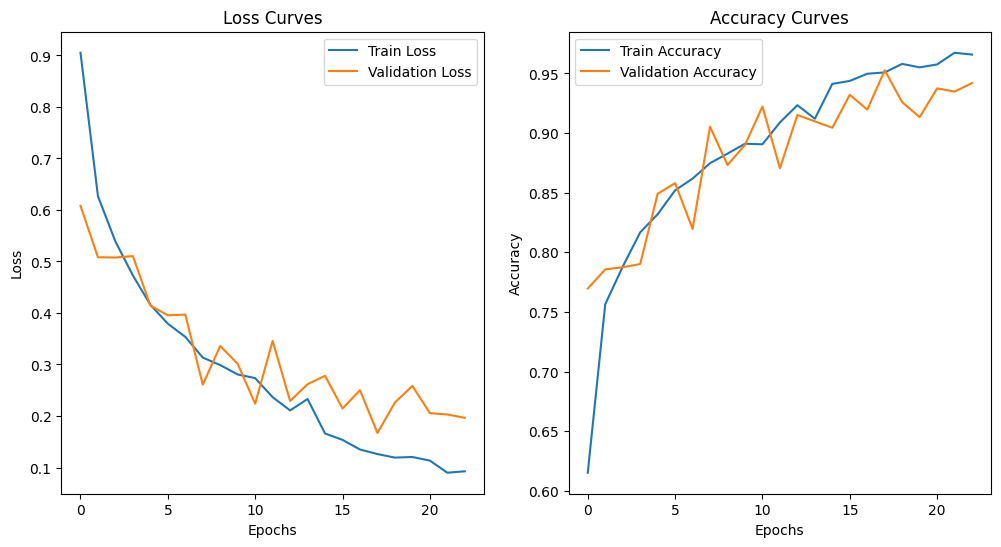

In [23]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Curves")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Curves")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 6) Model Evaluation

In [24]:
loss_test, accuracy_test = model.evaluate(test_data)

print(f"Test Loss: {loss_test:.2f}")
print(f"Test Accuracy: {accuracy_test:.2f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.8919 - loss: 0.7945
Test Loss: 0.79
Test Accuracy: 0.89


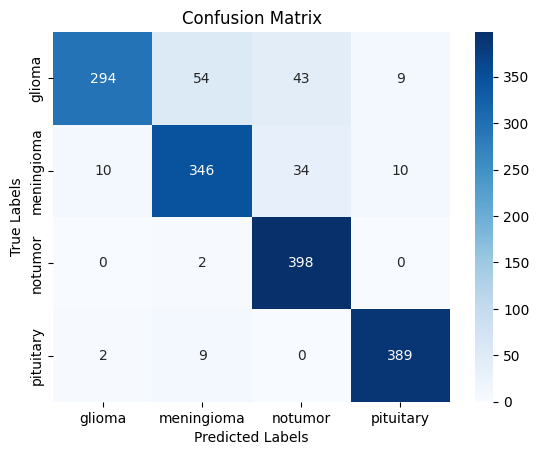

In [25]:
y_true = []
y_pred = []

for images, labels in test_data:

    y_true.extend(labels.numpy()) 

    predictions = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(predictions, axis=-1))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm,
            fmt="d",
             annot=True,
             cmap="Blues",
             xticklabels=['glioma', 'meningioma', 'notumor', 'pituitary'],
             yticklabels=['glioma', 'meningioma', 'notumor', 'pituitary'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

In [26]:
classification_rep = classification_report(
    y_true, 
    y_pred, 
    target_names=['glioma', 'meningioma', 'notumor', 'pituitary']
)
print(classification_rep)

              precision    recall  f1-score   support

      glioma       0.96      0.73      0.83       400
  meningioma       0.84      0.86      0.85       400
     notumor       0.84      0.99      0.91       400
   pituitary       0.95      0.97      0.96       400

    accuracy                           0.89      1600
   macro avg       0.90      0.89      0.89      1600
weighted avg       0.90      0.89      0.89      1600



# 7) Testing the model on individual images

In [27]:
def predict_image(image_path):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image = cv2.resize(image, (224, 224))
    image = image / 255.0
    image = np.expand_dims(image, axis=0)

    predictions = model.predict(image)
    predicted_class_index = np.argmax(predictions[0])
    predicted_class_name = class_names[predicted_class_index]
    
    return predicted_class_name

In [28]:
# Actual --> glioma
predict_image(r"/mnt/d/DeepLearning/datasets/Brain_Tumor_MRI/Testing/glioma/Te-gl_147.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 270ms/step


'glioma'

In [29]:
# Actual --> notumor
predict_image(r"/mnt/d/DeepLearning/datasets/Brain_Tumor_MRI/Testing/notumor/Te-no_28.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


'notumor'

In [30]:
model.save("brain_tumor_model.h5")